# Stage 5 — Satellite Data Acquisition (NAIP via Planetary Computer)

**Goal:** Download NAIP satellite imagery from Microsoft Planetary Computer (free, no API key),
clip it to the DEM extent + 50 m buffer, reproject to EPSG:26914, and export the files that
downstream VLM notebooks need.

**Outputs:**
| File | Purpose |
|------|---------|
| `data/input/cimarron_naip_rgb.tif` | 3-band GeoTIFF for GIS work |
| `data/input/cimarron_naip_rgbn.tif` | 4-band GeoTIFF (includes NIR) |
| `data/output/cimarron_satellite.png` | Clean RGB PNG for VLM notebooks |

**Dependencies:** `pystac-client`, `planetary-computer`, `rioxarray`, `rasterio`, `pyproj`, `shapely`

In [1]:
# Cell 1 — Install / verify dependencies
import importlib, subprocess, sys

_deps = {
    "pystac_client":       "pystac-client",
    "planetary_computer":  "planetary-computer",
    "rioxarray":           "rioxarray",
}

for mod, pkg in _deps.items():
    try:
        importlib.import_module(mod)
        print(f"  {pkg:<22s} OK")
    except ImportError:
        print(f"  {pkg:<22s} installing ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])
        print(f"  {pkg:<22s} installed")

print("\nAll dependencies ready.")

  pystac-client          OK
  planetary-computer     OK


  rioxarray              OK

All dependencies ready.


In [2]:
# Cell 2 — Imports & path configuration
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.merge import merge
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path
from PIL import Image
from pyproj import Transformer
from pystac_client import Client
import planetary_computer

# ---------- paths ----------
PROJECT_ROOT = Path("../..")
DEM_PATH       = PROJECT_ROOT / "data" / "input" / "1m elevation.tif"
RGB_TIFF_PATH  = PROJECT_ROOT / "data" / "input" / "cimarron_naip_rgb.tif"
RGBN_TIFF_PATH = PROJECT_ROOT / "data" / "input" / "cimarron_naip_rgbn.tif"
SATELLITE_PNG_PATH = PROJECT_ROOT / "data" / "output" / "cimarron_satellite.png"

for d in [RGB_TIFF_PATH.parent, SATELLITE_PNG_PATH.parent]:
    d.mkdir(parents=True, exist_ok=True)

# ---------- constants ----------
BUFFER_M   = 50
TARGET_CRS = "EPSG:26914"
STAC_URL   = "https://planetarycomputer.microsoft.com/api/stac/v1"

print(f"DEM exists: {DEM_PATH.exists()}")
print(f"Target CRS: {TARGET_CRS}")
print(f"Buffer:     {BUFFER_M} m")

DEM exists: True
Target CRS: EPSG:26914
Buffer:     50 m


In [3]:
# Cell 3 — Load DEM metadata & compute buffered bbox
with rasterio.open(DEM_PATH) as src:
    dem_bounds = src.bounds
    dem_crs    = src.crs
    dem_res    = src.res
    dem_shape  = (src.height, src.width)

print(f"DEM CRS:    {dem_crs}")
print(f"DEM shape:  {dem_shape}")
print(f"DEM res:    {dem_res}")
print(f"DEM bounds: {dem_bounds}")

# Buffered bounds in UTM
utm_left   = dem_bounds.left   - BUFFER_M
utm_bottom = dem_bounds.bottom - BUFFER_M
utm_right  = dem_bounds.right  + BUFFER_M
utm_top    = dem_bounds.top    + BUFFER_M

print(f"\nBuffered UTM bounds (+{BUFFER_M} m):")
print(f"  left={utm_left:.1f}, bottom={utm_bottom:.1f}, right={utm_right:.1f}, top={utm_top:.1f}")

# Convert to WGS84 for STAC query
transformer = Transformer.from_crs(dem_crs, "EPSG:4326", always_xy=True)
lon_min, lat_min = transformer.transform(utm_left, utm_bottom)
lon_max, lat_max = transformer.transform(utm_right, utm_top)
wgs84_bbox = [lon_min, lat_min, lon_max, lat_max]

print(f"\nWGS84 bbox for STAC query:")
print(f"  {wgs84_bbox}")

DEM CRS:    EPSG:26914
DEM shape:  (3088, 5306)
DEM res:    (1.0, 1.0)
DEM bounds: BoundingBox(left=645114.9999575217, bottom=3982702.00003351, right=650420.9999575217, top=3985790.00003351)

Buffered UTM bounds (+50 m):
  left=645065.0, bottom=3982652.0, right=650471.0, top=3985840.0

WGS84 bbox for STAC query:
  [-97.39097169162078, 35.97752085906053, -97.33042655510367, 36.005432533205315]


In [4]:
# Cell 4 — Query Planetary Computer STAC API
catalog = Client.open(STAC_URL, modifier=planetary_computer.sign_inplace)

search = catalog.search(
    collections=["naip"],
    bbox=wgs84_bbox,
    datetime="2020-01-01/2024-12-31",
)

items = list(search.items())
print(f"Found {len(items)} NAIP item(s):\n")

for item in items:
    props = item.properties
    print(f"  {item.id}")
    print(f"    date: {item.datetime}")
    print(f"    GSD:  {props.get('gsd', 'N/A')} m")
    print(f"    state: {props.get('naip:state', 'N/A')}")
    print()

Found 8 NAIP item(s):

  ok_m_3609762_sw_14_030_20230615_20230927
    date: 2023-06-15 16:00:00+00:00
    GSD:  0.3 m
    state: ok

  ok_m_3609761_se_14_030_20230615_20230927
    date: 2023-06-15 16:00:00+00:00
    GSD:  0.3 m
    state: ok

  ok_m_3509706_nw_14_030_20230615_20230927
    date: 2023-06-15 16:00:00+00:00
    GSD:  0.3 m
    state: ok

  ok_m_3509705_ne_14_030_20230615_20230927
    date: 2023-06-15 16:00:00+00:00
    GSD:  0.3 m
    state: ok

  ok_m_3609762_sw_14_060_20210506
    date: 2021-05-06 16:00:00+00:00
    GSD:  0.6 m
    state: ok

  ok_m_3609761_se_14_060_20210506
    date: 2021-05-06 16:00:00+00:00
    GSD:  0.6 m
    state: ok

  ok_m_3509706_nw_14_060_20210506
    date: 2021-05-06 16:00:00+00:00
    GSD:  0.6 m
    state: ok

  ok_m_3509705_ne_14_060_20210506
    date: 2021-05-06 16:00:00+00:00
    GSD:  0.6 m
    state: ok



In [5]:
# Cell 5 — Select best vintage
from collections import defaultdict

by_year = defaultdict(list)
for item in items:
    year = item.datetime.year
    by_year[year].append(item)

print("Items by year:")
for year in sorted(by_year.keys(), reverse=True):
    print(f"  {year}: {len(by_year[year])} item(s)")

# Prefer 2023 > 2021 > most recent available
preferred_years = [2023, 2021]
selected_year = None
for y in preferred_years:
    if y in by_year:
        selected_year = y
        break
if selected_year is None:
    selected_year = max(by_year.keys())

selected_items = by_year[selected_year]
print(f"\nSelected year: {selected_year} ({len(selected_items)} item(s))")
for item in selected_items:
    print(f"  {item.id}  —  {item.datetime.date()}")

Items by year:
  2023: 4 item(s)
  2021: 4 item(s)

Selected year: 2023 (4 item(s))
  ok_m_3609762_sw_14_030_20230615_20230927  —  2023-06-15
  ok_m_3609761_se_14_030_20230615_20230927  —  2023-06-15
  ok_m_3509706_nw_14_030_20230615_20230927  —  2023-06-15
  ok_m_3509705_ne_14_030_20230615_20230927  —  2023-06-15


In [6]:
# Cell 6 — Download, merge & clip in one pass (avoids tile alignment issues)
#
# rasterio.merge.merge with bounds= opens each COG, reads only the needed
# window, and composites everything onto a single consistent pixel grid.
# res=0.6 resamples from native 0.3 m to 0.6 m (matches DEM-scale analysis).

OUTPUT_RES = 0.6

datasets = []
for item in selected_items:
    href = item.assets["image"].href
    print(f"Opening COG: {item.id}")
    ds = rasterio.open(href)
    datasets.append(ds)
    print(f"  CRS={ds.crs}  native_res={ds.res}  bounds={ds.bounds}")

naip_crs = datasets[0].crs
target_bounds = (utm_left, utm_bottom, utm_right, utm_top)

# If NAIP tiles are not in TARGET_CRS, transform the clip bounds
if str(naip_crs) != TARGET_CRS:
    to_naip = Transformer.from_crs(TARGET_CRS, naip_crs, always_xy=True)
    nl, nb = to_naip.transform(utm_left, utm_bottom)
    nr, nt = to_naip.transform(utm_right, utm_top)
    merge_bounds = (nl, nb, nr, nt)
else:
    merge_bounds = target_bounds

print(f"\nMerging {len(datasets)} tiles to bounds {merge_bounds} at {OUTPUT_RES} m ...")
merged_data, merged_transform = merge(
    datasets, bounds=merge_bounds, res=OUTPUT_RES, resampling=Resampling.bilinear,
)

for ds in datasets:
    ds.close()

print(f"Merged shape: {merged_data.shape}, dtype: {merged_data.dtype}")

Opening COG: ok_m_3609762_sw_14_030_20230615_20230927


  CRS=EPSG:26914  native_res=(0.3, 0.3)  bounds=BoundingBox(left=646047.6, bottom=3984869.0999999996, right=652397.1, top=3992497.8)
Opening COG: ok_m_3609761_se_14_030_20230615_20230927


  CRS=EPSG:26914  native_res=(0.3, 0.3)  bounds=BoundingBox(left=640418.4, bottom=3984777.0, right=646763.4, top=3992402.1)
Opening COG: ok_m_3509706_nw_14_030_20230615_20230927


  CRS=EPSG:26914  native_res=(0.3, 0.3)  bounds=BoundingBox(left=646163.4, bottom=3977936.0999999996, right=652517.1, top=3985564.8)
Opening COG: ok_m_3509705_ne_14_030_20230615_20230927


  CRS=EPSG:26914  native_res=(0.3, 0.3)  bounds=BoundingBox(left=640529.7, bottom=3977844.0, right=646878.8999999999, top=3985469.1)

Merging 4 tiles to bounds (645064.9999575217, 3982652.00003351, 650470.9999575217, 3985840.00003351) at 0.6 m ...


Merged shape: (4, 5313, 9010), dtype: uint8


In [7]:
# Cell 7 — Reproject (if needed) & save GeoTIFFs
import tempfile, os

n_bands, src_h, src_w = merged_data.shape

# Check if reprojection is needed
needs_reproject = str(naip_crs) != TARGET_CRS

if needs_reproject:
    print(f"Reprojecting {naip_crs} → {TARGET_CRS} ...")
    dst_transform, dst_width, dst_height = calculate_default_transform(
        naip_crs, TARGET_CRS, src_w, src_h, *merge_bounds, resolution=0.6,
    )
    dst_data = np.zeros((n_bands, dst_height, dst_width), dtype=merged_data.dtype)
    for i in range(n_bands):
        reproject(
            source=merged_data[i],
            destination=dst_data[i],
            src_transform=merged_transform, src_crs=naip_crs,
            dst_transform=dst_transform, dst_crs=TARGET_CRS,
            resampling=Resampling.bilinear,
        )
    arr = dst_data
    out_transform = dst_transform
    out_h, out_w = dst_height, dst_width
else:
    arr = merged_data
    out_transform = merged_transform
    out_h, out_w = src_h, src_w

profile = {
    "driver": "GTiff",
    "dtype": arr.dtype,
    "width": out_w,
    "height": out_h,
    "crs": TARGET_CRS,
    "transform": out_transform,
    "compress": "deflate",
    "tiled": True,
    "blockxsize": 256,
    "blockysize": 256,
}

# 4-band RGBN
with rasterio.open(RGBN_TIFF_PATH, "w", count=n_bands, **profile) as dst:
    for i in range(n_bands):
        dst.write(arr[i], i + 1)
print(f"Saved {n_bands}-band RGBN: {RGBN_TIFF_PATH}")
print(f"  size: {RGBN_TIFF_PATH.stat().st_size / 1e6:.1f} MB")

# 3-band RGB
with rasterio.open(RGB_TIFF_PATH, "w", count=3, **profile) as dst:
    for i in range(3):
        dst.write(arr[i], i + 1)
print(f"Saved 3-band RGB:  {RGB_TIFF_PATH}")
print(f"  size: {RGB_TIFF_PATH.stat().st_size / 1e6:.1f} MB")

transform = out_transform
h, w = out_h, out_w
print(f"  dimensions: {w} x {h} px")

Saved 4-band RGBN: ../../data/input/cimarron_naip_rgbn.tif
  size: 158.1 MB


Saved 3-band RGB:  ../../data/input/cimarron_naip_rgb.tif
  size: 110.9 MB
  dimensions: 9010 x 5313 px


In [8]:
# Cell 8 — Export clean PNG (no axes, labels, or borders)
rgb_arr = np.moveaxis(arr[:3], 0, -1)  # (H, W, 3) uint8

img = Image.fromarray(rgb_arr.astype(np.uint8))
img.save(SATELLITE_PNG_PATH)

print(f"Saved PNG: {SATELLITE_PNG_PATH}")
print(f"  dimensions: {img.size[0]} x {img.size[1]} px")
print(f"  size: {SATELLITE_PNG_PATH.stat().st_size / 1e6:.1f} MB")

Saved PNG: ../../data/output/cimarron_satellite.png
  dimensions: 9010 x 5313 px
  size: 92.0 MB


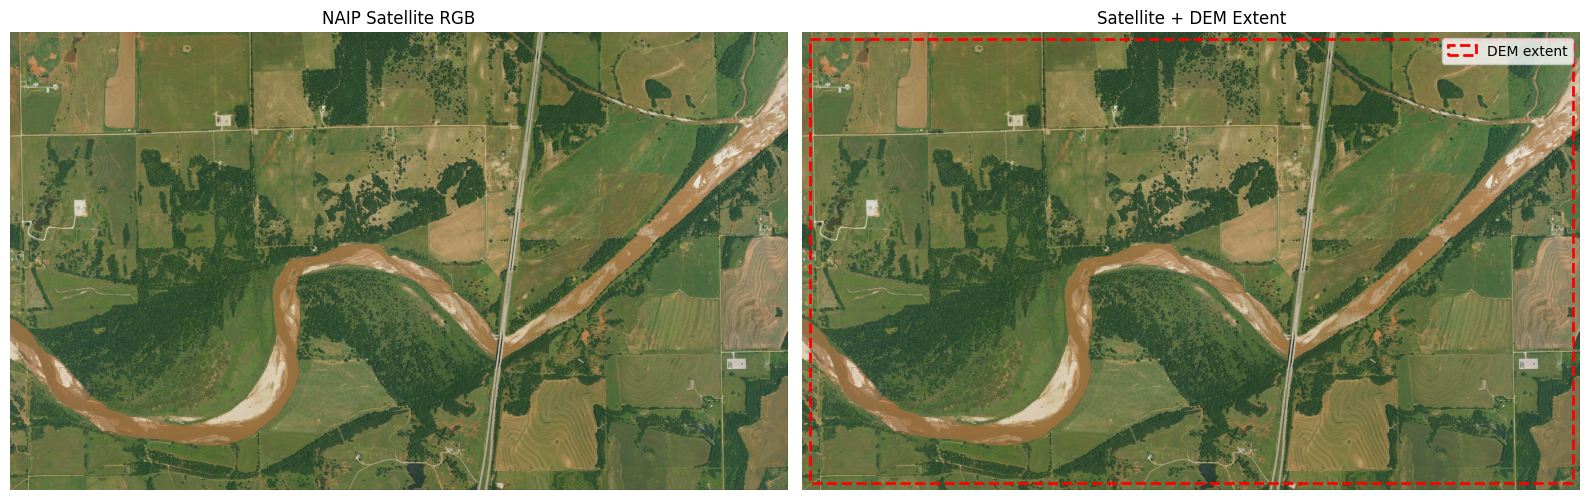

The 50 m buffer should be visible on all sides of the red rectangle.


In [9]:
# Cell 9 — Preview: satellite RGB + satellite with DEM extent overlay
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: satellite RGB
axes[0].imshow(rgb_arr)
axes[0].set_title("NAIP Satellite RGB")
axes[0].set_axis_off()

# Panel 2: satellite with DEM extent rectangle
axes[1].imshow(rgb_arr)
axes[1].set_title("Satellite + DEM Extent")

# Convert DEM bounds from UTM to pixel coords in the clipped image
inv_transform = ~transform
px_left,  px_top    = inv_transform * (dem_bounds.left,  dem_bounds.top)
px_right, px_bottom = inv_transform * (dem_bounds.right, dem_bounds.bottom)

rect = Rectangle(
    (px_left, px_top),
    px_right - px_left,
    px_bottom - px_top,
    linewidth=2, edgecolor="red", facecolor="none", linestyle="--",
    label="DEM extent",
)
axes[1].add_patch(rect)
axes[1].legend(loc="upper right")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()
print("The 50 m buffer should be visible on all sides of the red rectangle.")

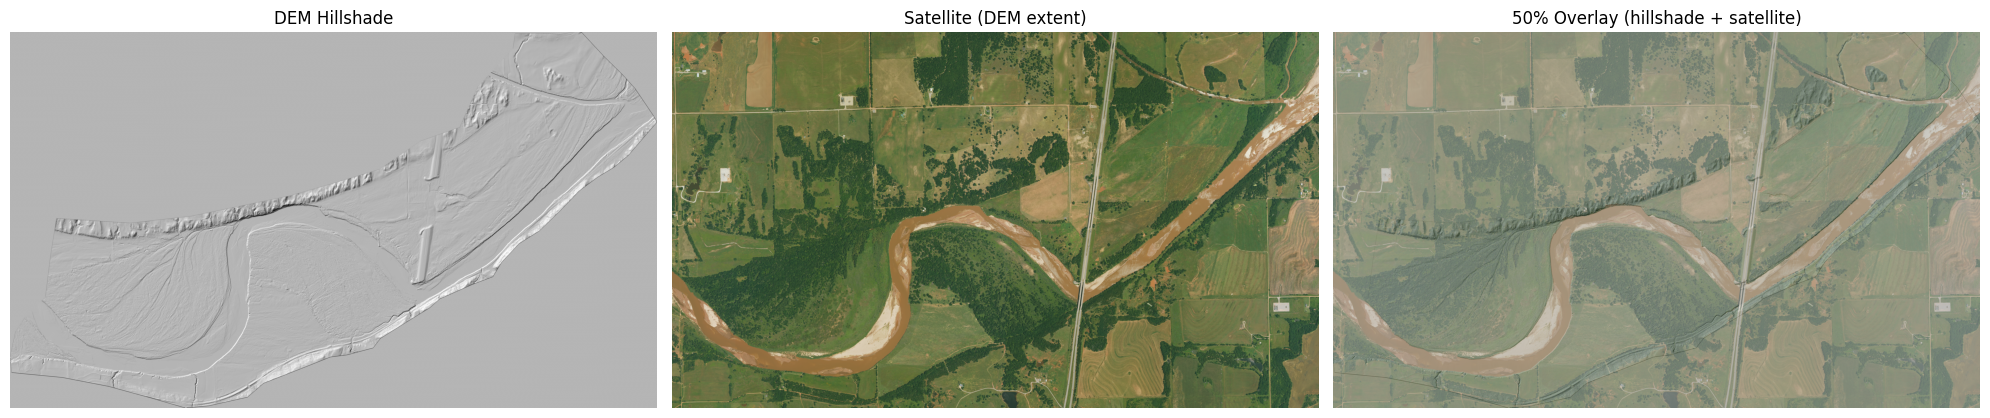

Check: river channel, roads, and terrain features should visually align.


In [10]:
# Cell 10 — Alignment verification: hillshade | satellite | overlay

def compute_hillshade(elev, azimuth=315, altitude=45, cell_size=1.0):
    """Compute hillshade from elevation array."""
    az_rad = np.radians(azimuth)
    alt_rad = np.radians(altitude)
    dy, dx = np.gradient(np.nan_to_num(elev, nan=0.0), cell_size)
    slope = np.arctan(np.sqrt(dx**2 + dy**2))
    aspect = np.arctan2(-dy, dx)
    hs = (np.cos(alt_rad) * np.cos(slope)
          + np.sin(alt_rad) * np.sin(slope) * np.cos(az_rad - aspect))
    hs = np.clip(hs, 0, 1)
    hs[np.isnan(elev)] = np.nan
    return hs

with rasterio.open(DEM_PATH) as src:
    elev = src.read(1)

hillshade = compute_hillshade(elev)

# Resize satellite to match DEM dimensions for overlay
sat_resized = np.array(img.resize((elev.shape[1], elev.shape[0]), Image.LANCZOS))

# Crop satellite to DEM extent (remove buffer pixels)
# Compute pixel offset of DEM extent within the clipped satellite
px_l, px_t = inv_transform * (dem_bounds.left, dem_bounds.top)
px_r, px_b = inv_transform * (dem_bounds.right, dem_bounds.bottom)
px_l, px_t, px_r, px_b = int(round(px_l)), int(round(px_t)), int(round(px_r)), int(round(px_b))
sat_dem_extent = rgb_arr[px_t:px_b, px_l:px_r]

# Resize cropped satellite to DEM pixel dimensions for clean overlay
sat_for_overlay = np.array(
    Image.fromarray(sat_dem_extent).resize((elev.shape[1], elev.shape[0]), Image.LANCZOS)
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(hillshade, cmap="gray")
axes[0].set_title("DEM Hillshade")
axes[0].set_axis_off()

axes[1].imshow(sat_for_overlay)
axes[1].set_title("Satellite (DEM extent)")
axes[1].set_axis_off()

# 50% overlay
hs_rgb = plt.cm.gray(hillshade)[:, :, :3]
hs_rgb = (hs_rgb * 255).astype(np.uint8)
blended = ((hs_rgb.astype(float) + sat_for_overlay.astype(float)) / 2).astype(np.uint8)
axes[2].imshow(blended)
axes[2].set_title("50% Overlay (hillshade + satellite)")
axes[2].set_axis_off()

plt.tight_layout()
plt.show()
print("Check: river channel, roads, and terrain features should visually align.")

In [11]:
# Cell 11 — Metadata summary
outputs = [
    ("RGB GeoTIFF",  RGB_TIFF_PATH),
    ("RGBN GeoTIFF", RGBN_TIFF_PATH),
    ("Satellite PNG", SATELLITE_PNG_PATH),
]

print("=" * 60)
print("SATELLITE ACQUISITION — SUMMARY")
print("=" * 60)
print(f"  Source:      NAIP via Microsoft Planetary Computer")
print(f"  Collection:  naip")
print(f"  Year:        {selected_year}")
print(f"  Items used:  {len(selected_items)}")
print(f"  Resolution:  {OUTPUT_RES} m/px")
print(f"  CRS:         {TARGET_CRS}")
print(f"  Buffer:      {BUFFER_M} m around DEM extent")
print(f"  Clipped px:  {w} x {h}")
print()

all_ok = True
for label, path in outputs:
    exists = path.exists()
    size_mb = path.stat().st_size / 1e6 if exists else 0
    status = f"{size_mb:.1f} MB" if exists else "MISSING"
    print(f"  [{('OK' if exists else 'XX'):>2s}] {label:<16s} {str(path):<50s} {status}")
    if not exists:
        all_ok = False

print()
if all_ok:
    print("All output files present. Ready for downstream VLM notebooks.")
else:
    print("WARNING: Some output files are missing!")

SATELLITE ACQUISITION — SUMMARY
  Source:      NAIP via Microsoft Planetary Computer
  Collection:  naip
  Year:        2023
  Items used:  4
  Resolution:  0.6 m/px
  CRS:         EPSG:26914
  Buffer:      50 m around DEM extent
  Clipped px:  9010 x 5313

  [OK] RGB GeoTIFF      ../../data/input/cimarron_naip_rgb.tif             110.9 MB
  [OK] RGBN GeoTIFF     ../../data/input/cimarron_naip_rgbn.tif            158.1 MB
  [OK] Satellite PNG    ../../data/output/cimarron_satellite.png           92.0 MB

All output files present. Ready for downstream VLM notebooks.
